Cell 1: Khởi tạo, import thư viện và tải dữ liệu an toàn VIF

In [1]:
import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, StackingRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Đường dẫn đến thư mục chứa dữ liệu từ file 05
data_dir = os.path.join('..', 'data', 'processed')

train_df = pd.read_csv(os.path.join(data_dir, 'train.csv'))
val_df = pd.read_csv(os.path.join(data_dir, 'validation.csv'))
test_df = pd.read_csv(os.path.join(data_dir, 'test.csv'))

# Tách đặc trưng và nhãn target_price_log
X_train = train_df.drop(columns=['target_price_log']).values
y_train = train_df['target_price_log'].values

X_val = val_df.drop(columns=['target_price_log']).values
y_val = val_df['target_price_log'].values

X_test = test_df.drop(columns=['target_price_log']).values
y_test = test_df['target_price_log'].values

print("ĐÃ TẢI MA TRẬN DỮ LIỆU SẠCH AN TOÀN VIF:")
print(f"- Tập Train: {X_train.shape} | Tập Validation: {X_val.shape} | Tập Test: {X_test.shape}")

ĐÃ TẢI MA TRẬN DỮ LIỆU SẠCH AN TOÀN VIF:
- Tập Train: (1421, 14) | Tập Validation: (474, 14) | Tập Test: (474, 14)


Cell 2: Hàm Nghiệm thu Thực nghiệm (Lưu kết quả)

In [2]:
all_results = {}

def evaluate_experiment(model_name, y_true_log, y_pred_log):
    r2 = r2_score(y_true_log, y_pred_log)
    mae = mean_absolute_error(y_true_log, y_pred_log)
    rmse = root_mean_squared_error(y_true_log, y_pred_log)
    
    print(f" KẾT QUẢ HIỆU NĂNG MÔ HÌNH: {model_name}")
    print(f"  - R2 Score (Độ giải thích): {r2:.4f}")
    print(f"  - MAE (Sai số tuyệt đối):   {mae:.4f}")
    print(f"  - RMSE (Sai số căn bình phương): {rmse:.4f}")
    print("-" * 50)
    
    all_results[model_name] = {"R2": r2, "MAE": mae, "RMSE": rmse}
    return all_results[model_name]

Cell 3: Gom hết các cell Khảo sát tham số

In [3]:
# 1. Khảo sát Ridge
ridge_param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}
grid_ridge = GridSearchCV(Ridge(random_state=42), ridge_param_grid, cv=5, scoring='r2')
grid_ridge.fit(X_train, y_train)

# 2. Khảo sát Decision Tree
tree_param_grid = {
    'max_depth': [5, 8, 12, 15],
    'min_samples_split': [5, 10, 20],
    'max_features': ['sqrt', None]
}
grid_tree = GridSearchCV(DecisionTreeRegressor(random_state=42), tree_param_grid, cv=5, scoring='r2')
grid_tree.fit(X_train, y_train)

# 3. Khảo sát Random Forest
rf_param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [4, 8, 12],
    'max_features': ['sqrt', None]
}
random_rf = RandomizedSearchCV(RandomForestRegressor(random_state=42), rf_param_dist, n_iter=8, cv=5, scoring='r2', random_state=42, n_jobs=-1)
random_rf.fit(X_train, y_train)

print("-> Hoàn thành toàn bộ quy trình khảo sát Hyperparameters!")
print(f"Best Ridge: {grid_ridge.best_params_}")
print(f"Best Tree: {grid_tree.best_params_}")
print(f"Best RF: {random_rf.best_params_}")

-> Hoàn thành toàn bộ quy trình khảo sát Hyperparameters!
Best Ridge: {'alpha': 1.0}
Best Tree: {'max_depth': 15, 'max_features': None, 'min_samples_split': 20}
Best RF: {'n_estimators': 50, 'min_samples_split': 8, 'max_features': None, 'max_depth': 20}


Cell 4: Các thuật toán từ Scratch

In [4]:
# --- LINEAR REGRESSION SCRATCH ---
class LinearRegressionScratchGD:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def forward(self, X): return np.dot(X, self.weights) + self.bias
    def compute_loss(self, y_true, y_pred): return np.mean((y_pred - y_true) ** 2)
    def compute_gradients(self, X, y_true, y_pred):
        n_samples = X.shape[0]
        dw = (2 / n_samples) * np.dot(X.T, (y_pred - y_true))
        db = (2 / n_samples) * np.sum(y_pred - y_true)
        return dw, db
    def update_parameters(self, dw, db):
        self.weights -= self.lr * dw
        self.bias -= self.lr * db
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        for epoch in range(self.epochs):
            y_pred = self.forward(X)
            dw, db = self.compute_gradients(X, y, y_pred)
            self.update_parameters(dw, db)

    def predict(self, X): return self.forward(X)

# --- RIDGE REGRESSION SCRATCH ---
class RidgeRegressionScratchGD:
    def __init__(self, alpha=1.0, lr=0.01, epochs=1000):
        self.alpha = alpha
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def forward(self, X): return np.dot(X, self.weights) + self.bias
    def compute_gradients(self, X, y_true, y_pred):
        n_samples = X.shape[0]
        dw = (2 / n_samples) * (np.dot(X.T, (y_pred - y_true)) + self.alpha * self.weights)
        db = (2 / n_samples) * np.sum(y_pred - y_true)
        return dw, db
    def update_parameters(self, dw, db):
        self.weights -= self.lr * dw
        self.bias -= self.lr * db
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        for epoch in range(self.epochs):
            y_pred = self.forward(X)
            dw, db = self.compute_gradients(X, y, y_pred)
            self.update_parameters(dw, db)

    def predict(self, X): return self.forward(X)

# --- DECISION TREE SCRATCH ---
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

class DecisionTreeRegressorScratch:
    def __init__(self, min_samples_split=10, max_depth=6):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.root = None

    def _variance_reduction(self, y, left_idxs, right_idxs):
        parent_variance = np.var(y) * len(y)
        left_variance = np.var(y[left_idxs]) * len(left_idxs)
        right_variance = np.var(y[right_idxs]) * len(right_idxs)
        return parent_variance - (left_variance + right_variance)

    def _best_split(self, X, y, n_features):
        best_vr = -1
        split_idx, split_thresh = None, None
        for feat_idx in range(n_features):
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            for thresh in thresholds:
                left_idxs = np.where(X_column <= thresh)[0]
                right_idxs = np.where(X_column > thresh)[0]
                if len(left_idxs) == 0 or len(right_idxs) == 0: continue
                vr = self._variance_reduction(y, left_idxs, right_idxs)
                if vr > best_vr:
                    best_vr = vr
                    split_idx = feat_idx
                    split_thresh = thresh
        return split_idx, split_thresh

    def _build_tree(self, X, y, depth):
        n_samples, n_features = X.shape
        if depth >= self.max_depth or n_samples < self.min_samples_split or np.var(y) == 0:
            return Node(value=np.mean(y))
        best_feat, best_thresh = self._best_split(X, y, n_features)
        if best_feat is None: return Node(value=np.mean(y))
        left_idxs = np.where(X[:, best_feat] <= best_thresh)[0]
        right_idxs = np.where(X[:, best_feat] > best_thresh)[0]
        left_child = self._build_tree(X[left_idxs], y[left_idxs], depth + 1)
        right_child = self._build_tree(X[right_idxs], y[right_idxs], depth + 1)
        return Node(feature=best_feat, threshold=best_thresh, left=left_child, right=right_child)

    def fit(self, X, y): self.root = self._build_tree(X, y, 0)
    def predict(self, X): return np.array([self._traverse_tree(x, self.root) for x in X])
    def _traverse_tree(self, x, node):
        if node.value is not None: return node.value
        if x[node.feature] <= node.threshold: return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

# --- RANDOM FOREST SCRATCH ---
class RandomForestRegressorScratch:
    def __init__(self, n_trees=5, max_depth=6, min_samples_split=10):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []
    def _bootstrap_sample(self, X, y):
        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, n_samples, replace=True)
        return X[indices], y[indices]
    def fit(self, X, y):
        self.trees = []
        for i in range(self.n_trees):
            tree = DecisionTreeRegressorScratch(max_depth=self.max_depth, min_samples_split=self.min_samples_split)
            X_sample, y_sample = self._bootstrap_sample(X, y)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
    def predict(self, X):
        all_tree_preds = np.array([tree.predict(X) for tree in self.trees])
        return np.mean(all_tree_preds, axis=0)

Cell 5: Huấn luyện và Đánh giá các mô hình từ Scratch

In [5]:
# 1. Linear Regression Scratch
lr_scratch = LinearRegressionScratchGD(lr=0.05, epochs=1000)
lr_scratch.fit(X_train, y_train)
evaluate_experiment("Linear Regression (Scratch)", y_val, lr_scratch.predict(X_val))

# 2. Ridge Scratch (Dùng alpha tối ưu vừa tìm được)
ridge_scratch = RidgeRegressionScratchGD(alpha=grid_ridge.best_params_['alpha'], lr=0.05, epochs=1000)
ridge_scratch.fit(X_train, y_train)
evaluate_experiment("Ridge Regression GD (Scratch)", y_val, ridge_scratch.predict(X_val))

# 3. Decision Tree Scratch (Dùng max_depth và min_samples_split tối ưu)
tree_scratch = DecisionTreeRegressorScratch(min_samples_split=grid_tree.best_params_['min_samples_split'], max_depth=grid_tree.best_params_['max_depth'])
tree_scratch.fit(X_train, y_train)
evaluate_experiment("Decision Tree (Scratch)", y_val, tree_scratch.predict(X_val))

# 4. Random Forest Scratch
rf_scratch = RandomForestRegressorScratch(n_trees=5, max_depth=6, min_samples_split=10)
rf_scratch.fit(X_train, y_train)
evaluate_experiment("Random Forest (Scratch)", y_val, rf_scratch.predict(X_val))

 KẾT QUẢ HIỆU NĂNG MÔ HÌNH: Linear Regression (Scratch)
  - R2 Score (Độ giải thích): 0.5687
  - MAE (Sai số tuyệt đối):   0.3372
  - RMSE (Sai số căn bình phương): 0.4491
--------------------------------------------------
 KẾT QUẢ HIỆU NĂNG MÔ HÌNH: Ridge Regression GD (Scratch)
  - R2 Score (Độ giải thích): 0.5688
  - MAE (Sai số tuyệt đối):   0.3372
  - RMSE (Sai số căn bình phương): 0.4490
--------------------------------------------------
 KẾT QUẢ HIỆU NĂNG MÔ HÌNH: Decision Tree (Scratch)
  - R2 Score (Độ giải thích): 0.6729
  - MAE (Sai số tuyệt đối):   0.2828
  - RMSE (Sai số căn bình phương): 0.3911
--------------------------------------------------
 KẾT QUẢ HIỆU NĂNG MÔ HÌNH: Random Forest (Scratch)
  - R2 Score (Độ giải thích): 0.7090
  - MAE (Sai số tuyệt đối):   0.2732
  - RMSE (Sai số căn bình phương): 0.3688
--------------------------------------------------


{'R2': 0.7090450983763037,
 'MAE': 0.2731815977579534,
 'RMSE': 0.3688378552301028}

Lập trình thuật toán Random Forest Regressor từ gốc bằng NumPy

In [6]:
class RandomForestRegressorScratch:
    # BƯỚC 1: KHỞI TẠO SIÊU THAM SỐ RỪNG (Forest Hyperparameters Initialization)
    def __init__(self, n_trees=5, max_depth=6, min_samples_split=10):
        self.n_trees = n_trees                 # Số lượng cây quyết định trong rừng
        self.max_depth = max_depth             # Độ sâu tối đa của mỗi cây thành phần
        self.min_samples_split = min_samples_split # Số mẫu tối thiểu để tiếp tục phân nhánh
        self.trees = []                        # Danh sách lưu trữ các cây sau khi huấn luyện

    # BƯỚC 2: KỸ THUẬT LẤY MẪU BOOTSTRAP (Bootstrap Sampling / Bagging)
    def _bootstrap_sample(self, X, y):
        n_samples = X.shape[0]
        # Lấy mẫu ngẫu nhiên có lặp lại (replace=True) với kích thước bằng tập dữ liệu gốc
        indices = np.random.choice(n_samples, n_samples, replace=True)
        return X[indices], y[indices]

    # BƯỚC 3: XÂY DỰNG TẬP HỢP CÂY ĐỘC LẬP (Recursive Forest Construction)
    def fit(self, X, y):
        self.trees = [] # Reset lại danh sách rừng cây
        
        print(f"   [Forest Build] Tiến hành dựng {self.n_trees} cây quyết định độc lập...")
        for i in range(self.n_trees):
            # Khởi tạo một cây quyết định đơn lẻ từ cấu trúc Bước 1
            tree = DecisionTreeRegressorScratch(
                max_depth=self.max_depth, 
                min_samples_split=self.min_samples_split
            )
            # Gọi Bước 2 để tạo không gian dữ liệu Bootstrap riêng biệt cho cây này
            X_sample, y_sample = self._bootstrap_sample(X, y)
            
            # Huấn luyện cây con trên tập mẫu con tương ứng
            tree.fit(X_sample, y_sample)
            # Đóng gói cây đã huấn luyện vào hệ thống rừng
            self.trees.append(tree)
            print(f"     -> Hoàn thành kiến trúc Cây thứ {i+1}/{self.n_trees}")

    # BƯỚC 4: THU THẬP DỰ ĐOÁN TỪ TỪNG CÂY THÀNH PHẦN (Individual Tree Inference)
    def _collect_tree_predictions(self, X):
        # Duyệt qua từng cây trong rừng để lấy vector dự đoán độc lập của cây đó
        return np.array([tree.predict(X) for tree in self.trees])

    # BƯỚC 5: TỔNG HỢP VÀ LẤY TRUNG BÌNH KẾT QUẢ (Aggregation / Prediction)
    def predict(self, X):
        # Thu thập ma trận dự đoán từ Bước 4 (Kích thước: [n_trees, n_samples])
        all_tree_preds = self._collect_tree_predictions(X)
        
        # Áp dụng cơ chế Aggregation: Lấy trung bình cộng dự đoán của tất cả các cây (axis=0)
        # Đây là công thức cốt lõi giúp giảm phương sai (Variance) cho bài toán hồi quy
        final_predictions = np.mean(all_tree_preds, axis=0)
        return final_predictions

# Huấn luyện mô hình Rừng quyết định quy trình Bagging từ Scratch
print("-> Đang huấn luyện Random Forest từ Scratch qua quy trình Bagging:")
rf_scratch = RandomForestRegressorScratch(n_trees=5, max_depth=6, min_samples_split=10)
rf_scratch.fit(X_train, y_train)
preds_rf_scratch = rf_scratch.predict(X_val)
evaluate_experiment("Random Forest (Scratch)", y_val, preds_rf_scratch)

-> Đang huấn luyện Random Forest từ Scratch qua quy trình Bagging:
   [Forest Build] Tiến hành dựng 5 cây quyết định độc lập...
     -> Hoàn thành kiến trúc Cây thứ 1/5
     -> Hoàn thành kiến trúc Cây thứ 2/5
     -> Hoàn thành kiến trúc Cây thứ 3/5
     -> Hoàn thành kiến trúc Cây thứ 4/5
     -> Hoàn thành kiến trúc Cây thứ 5/5
 KẾT QUẢ HIỆU NĂNG MÔ HÌNH: Random Forest (Scratch)
  - R2 Score (Độ giải thích): 0.7005
  - MAE (Sai số tuyệt đối):   0.2790
  - RMSE (Sai số căn bình phương): 0.3742
--------------------------------------------------


{'R2': 0.7004742941528224,
 'MAE': 0.27899079755642386,
 'RMSE': 0.37423094742721125}

Cell 6: Huấn luyện và Đánh giá các mô hình từ Thư viện (Library)

In [7]:
# 1. Ridge Lib
best_ridge = grid_ridge.best_estimator_
best_ridge.fit(X_train, y_train)
evaluate_experiment("Ridge Regression (Tuned Lib)", y_val, best_ridge.predict(X_val))

# 2. Decision Tree Lib
best_tree = grid_tree.best_estimator_
best_tree.fit(X_train, y_train)
evaluate_experiment("Decision Tree (Tuned Lib)", y_val, best_tree.predict(X_val))

# 3. Random Forest Lib
best_rf = random_rf.best_estimator_
best_rf.fit(X_train, y_train)
preds_rf_lib = best_rf.predict(X_val)
evaluate_experiment("Random Forest (Tuned Lib)", y_val, preds_rf_lib)

 KẾT QUẢ HIỆU NĂNG MÔ HÌNH: Ridge Regression (Tuned Lib)
  - R2 Score (Độ giải thích): 0.5688
  - MAE (Sai số tuyệt đối):   0.3372
  - RMSE (Sai số căn bình phương): 0.4490
--------------------------------------------------
 KẾT QUẢ HIỆU NĂNG MÔ HÌNH: Decision Tree (Tuned Lib)
  - R2 Score (Độ giải thích): 0.6733
  - MAE (Sai số tuyệt đối):   0.2814
  - RMSE (Sai số căn bình phương): 0.3909
--------------------------------------------------
 KẾT QUẢ HIỆU NĂNG MÔ HÌNH: Random Forest (Tuned Lib)
  - R2 Score (Độ giải thích): 0.7788
  - MAE (Sai số tuyệt đối):   0.2288
  - RMSE (Sai số căn bình phương): 0.3216
--------------------------------------------------


{'R2': 0.7788271760795343,
 'MAE': 0.22880459307583556,
 'RMSE': 0.3215796294658891}

Cell 7: Các cell chạy Ensemble kỹ thuật cao (Voting & Stacking từ cả Thư viện và Scratch)

In [8]:
# --- VOTING & STACKING FROM SCRATCH ---
class VotingRegressorScratch:
    def __init__(self, estimators): self.estimators = estimators
    def fit(self, X, y):
        for name, model in self.estimators:
            if hasattr(model, 'epochs'): model.fit_to_silent = True
            model.fit(X, y)
    def predict(self, X):
        return np.mean(np.array([model.predict(X) for name, model in self.estimators]), axis=0)

class StackingRegressorScratch:
    def __init__(self, estimators, final_estimator, cv=5):
        self.estimators = estimators
        self.final_estimator = final_estimator
        self.cv = cv
    def fit(self, X, y):
        n_samples = X.shape[0]
        oof_features = np.zeros((n_samples, len(self.estimators)))
        indices = np.arange(n_samples)
        np.random.seed(42)
        np.random.shuffle(indices)
        folds = np.array_split(indices, self.cv)
        for fold_idx in range(self.cv):
            val_idxs = folds[fold_idx]
            train_idxs = np.setdiff1d(indices, val_idxs)
            for model_idx, (name, model) in enumerate(self.estimators):
                temp_model = copy.deepcopy(model)
                temp_model.fit(X[train_idxs], y[train_idxs])
                oof_features[val_idxs, model_idx] = temp_model.predict(X[val_idxs])
        self.final_estimator.fit(oof_features, y)
        for name, model in self.estimators: model.fit(X, y)
    def predict(self, X):
        meta_features = np.array([model.predict(X) for name, model in self.estimators]).T
        return self.final_estimator.predict(meta_features)

# Chạy Voting & Stacking Scratch
voting_scratch = VotingRegressorScratch([('ridge', ridge_scratch), ('tree', tree_scratch)])
voting_scratch.fit(X_train, y_train)
evaluate_experiment("Ensemble Voting (Scratch)", y_val, voting_scratch.predict(X_val))

meta_lr = LinearRegressionScratchGD(lr=0.01, epochs=500)
meta_lr.fit_to_silent = True
stacking_scratch = StackingRegressorScratch([('ridge', ridge_scratch), ('tree', tree_scratch), ('rf', rf_scratch)], meta_lr)
stacking_scratch.fit(X_train, y_train)
evaluate_experiment("Advanced Stacking (Scratch)", y_val, stacking_scratch.predict(X_val))

# --- VOTING & STACKING FROM LIBRARY ---
voting_model = VotingRegressor(estimators=[('ridge', best_ridge), ('rf', best_rf)])
voting_model.fit(X_train, y_train)
evaluate_experiment("Ensemble Voting (Ridge + RF)", y_val, voting_model.predict(X_val))

stacking_model = StackingRegressor(estimators=[('ridge', best_ridge), ('tree', best_tree), ('rf', best_rf)], final_estimator=LinearRegression(), cv=5, n_jobs=-1)
stacking_model.fit(X_train, y_train)
preds_stacking = stacking_model.predict(X_val)
evaluate_experiment("Advanced Stacking Regressor", y_val, preds_stacking)

 KẾT QUẢ HIỆU NĂNG MÔ HÌNH: Ensemble Voting (Scratch)
  - R2 Score (Độ giải thích): 0.7018
  - MAE (Sai số tuyệt đối):   0.2784
  - RMSE (Sai số căn bình phương): 0.3734
--------------------------------------------------
   [Forest Build] Tiến hành dựng 5 cây quyết định độc lập...
     -> Hoàn thành kiến trúc Cây thứ 1/5
     -> Hoàn thành kiến trúc Cây thứ 2/5
     -> Hoàn thành kiến trúc Cây thứ 3/5
     -> Hoàn thành kiến trúc Cây thứ 4/5
     -> Hoàn thành kiến trúc Cây thứ 5/5
   [Forest Build] Tiến hành dựng 5 cây quyết định độc lập...
     -> Hoàn thành kiến trúc Cây thứ 1/5
     -> Hoàn thành kiến trúc Cây thứ 2/5
     -> Hoàn thành kiến trúc Cây thứ 3/5
     -> Hoàn thành kiến trúc Cây thứ 4/5
     -> Hoàn thành kiến trúc Cây thứ 5/5
   [Forest Build] Tiến hành dựng 5 cây quyết định độc lập...
     -> Hoàn thành kiến trúc Cây thứ 1/5
     -> Hoàn thành kiến trúc Cây thứ 2/5
     -> Hoàn thành kiến trúc Cây thứ 3/5
     -> Hoàn thành kiến trúc Cây thứ 4/5
     -> Hoàn thành kiế

{'R2': 0.778882368604251,
 'MAE': 0.23050895186199458,
 'RMSE': 0.3215395027026846}

Cell 8: Bảng tổng sắp kết quả

 BẢNG TỔNG SẮP HIỆU NĂNG THÍ NGHIỆM TRÊN TẬP VALIDATION (SẮP XẾP THEO R2 CAO NHẤT):
          Mô hình Thực nghiệm       R2      MAE     RMSE
  Advanced Stacking Regressor 0.778882 0.230509 0.321540
    Random Forest (Tuned Lib) 0.778827 0.228805 0.321580
  Advanced Stacking (Scratch) 0.731082 0.264616 0.354595
 Ensemble Voting (Ridge + RF) 0.730063 0.261128 0.355266
    Ensemble Voting (Scratch) 0.701845 0.278364 0.373374
      Random Forest (Scratch) 0.700474 0.278991 0.374231
    Decision Tree (Tuned Lib) 0.673251 0.281361 0.390868
      Decision Tree (Scratch) 0.672860 0.282845 0.391102
Ridge Regression GD (Scratch) 0.568757 0.337189 0.449039
 Ridge Regression (Tuned Lib) 0.568757 0.337189 0.449039
  Linear Regression (Scratch) 0.568657 0.337219 0.449091


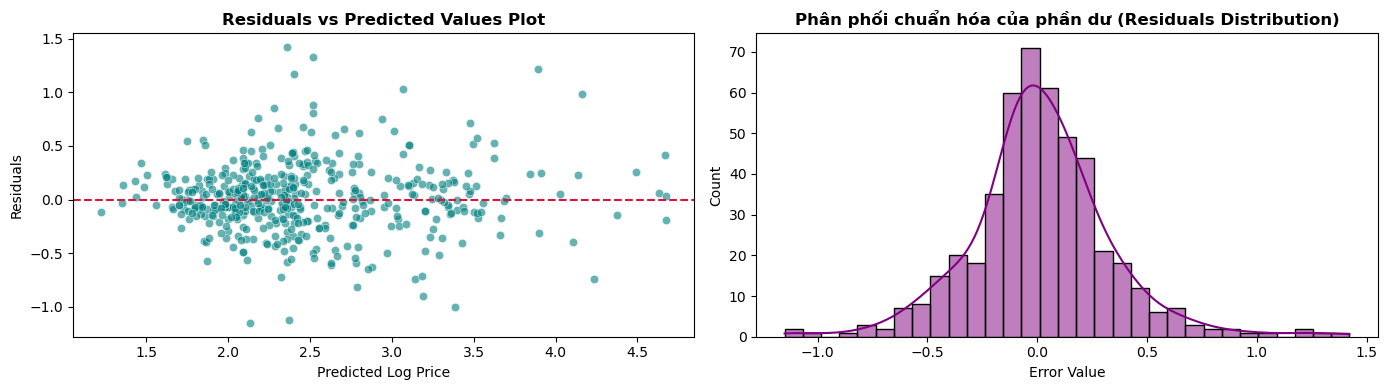

In [9]:
df_results = pd.DataFrame(all_results).T.reset_index().rename(columns={'index': 'Mô hình Thực nghiệm'})
df_results_sorted = df_results.sort_values(by="R2", ascending=False)

print(" BẢNG TỔNG SẮP HIỆU NĂNG THÍ NGHIỆM TRÊN TẬP VALIDATION (SẮP XẾP THEO R2 CAO NHẤT):")
print(df_results_sorted.to_string(index=False))

# Lấy dự đoán của mô hình tốt nhất để vẽ đồ thị phần dư
best_model_name = df_results_sorted.iloc[0]['Mô hình Thực nghiệm']
if "Stacking Regressor" in best_model_name:
    final_preds = preds_stacking
elif "Tuned Lib" in best_model_name:
    final_preds = preds_rf_lib
else:
    final_preds = stacking_scratch.predict(X_val)

residuals = y_val - final_preds

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.scatterplot(x=final_preds, y=residuals, ax=ax[0], alpha=0.6, color='teal')
ax[0].axhline(y=0, color='crimson', linestyle='--', linewidth=1.5)
ax[0].set_title('Residuals vs Predicted Values Plot', fontweight='bold')
ax[0].set_xlabel('Predicted Log Price')
ax[0].set_ylabel('Residuals')

sns.histplot(residuals, kde=True, ax=ax[1], color='purple')
ax[1].set_title('Phân phối chuẩn hóa của phần dư (Residuals Distribution)', fontweight='bold')
ax[1].set_xlabel('Error Value')

plt.tight_layout()
plt.show()

Lưu model

In [10]:
import joblib

# 1. Định nghĩa đường dẫn lưu file model (Lưu vào thư mục chứa dự án của ní)
model_dir = os.path.join('..', 'models')
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, 'best_stacking_regressor.pkl')

# 2. Tiến hành đóng gói và lưu mô hình Stacking
joblib.dump(stacking_model, model_path)
print(f"ĐÃ LƯU MÔ HÌNH XUẤT SẮC NHẤT THÀNH CÔNG TẠI: {model_path}")

ĐÃ LƯU MÔ HÌNH XUẤT SẮC NHẤT THÀNH CÔNG TẠI: ..\models\best_stacking_regressor.pkl
